## Data Source
This analysis uses monthly natural gas price data from October 2020 to September 2024.
The data file `Nat_Gas.csv` should be in the same directory as this notebook.

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [49]:
df = pd.read_csv('Nat_Gas.csv')
print(df.head(10))

      Dates  Prices
0  10/31/20   10.10
1  11/30/20   10.30
2  12/31/20   11.00
3   1/31/21   10.90
4   2/28/21   10.90
5   3/31/21   10.90
6   4/30/21   10.40
7   5/31/21    9.84
8   6/30/21   10.00
9   7/31/21   10.10


In [50]:
df['Dates'] = pd.to_datetime(df['Dates']) #to adjust date column in datetime format so that pd not think it as just text
df = df.sort_values('Dates') #for dates in correct order

/var/folders/2m/67dphvv56cgdmmmd32h2x7480000gn/T/ipykernel_2235/879796607.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates']) #to adjust date column in datetime format so that pd not think it as just text


In [51]:
df['Month'] = df['Dates'].dt.month
df['Year'] = df['Dates'].dt.year
df['Day'] = df['Dates'].dt.dayofyear

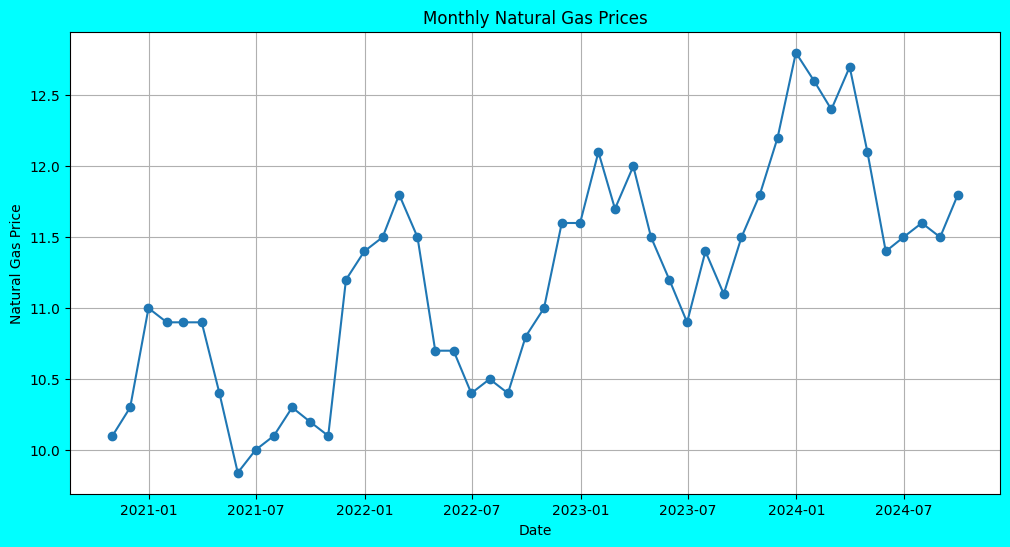

In [52]:
plt.figure(figsize=(12, 6), facecolor='cyan')
plt.plot(df['Dates'], df['Prices'], marker='o', linestyle='-')  # Change 'Price' to your column name
plt.xlabel('Date')
plt.ylabel('Natural Gas Price')
plt.title('Monthly Natural Gas Prices')
plt.grid(True)
plt.show()

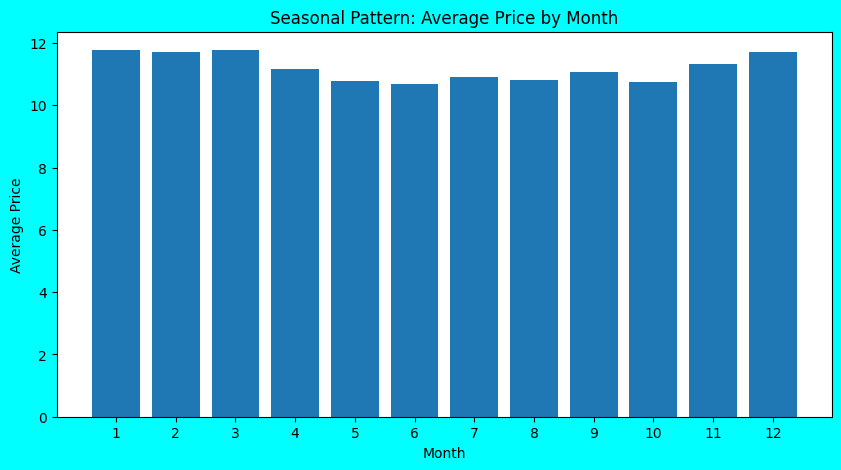

In [53]:
monthly_avg = df.groupby('Month')['Prices'].mean()
plt.figure(figsize=(10, 5), facecolor = 'cyan')
plt.bar(monthly_avg.index, monthly_avg.values)
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.title('Seasonal Pattern: Average Price by Month')
plt.xticks(range(1, 13))
plt.show()

In [54]:
#seasons repeat in a cycle(like a wave), so using cosine and sine functions for mapping days to an angle
df['sin_day'] = np.sin(2 * np.pi * df['Day'] / 365.25) #365.25 instead of 366 for considering leap year
df['cos_day'] = np.cos(2 * np.pi * df['Day'] / 365.25)

In [55]:
# Features: year, and cyclical day features
X = df[['Year', 'sin_day', 'cos_day']].values
y = df['Prices'].values

model = LinearRegression()
model.fit(X, y)  


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
def estimate_price(input_date):
    if isinstance(input_date, str):
        input_date = datetime.strptime(input_date, '%Y-%m-%d')

    year = input_date.year
    day_of_year = input_date.timetuple().tm_yday
    sin_day = np.sin(2 * np.pi * day_of_year / 365.25)
    cos_day = np.cos(2 * np.pi * day_of_year / 365.25)
 
    X_pred = np.array([[year, sin_day, cos_day]])
    predicted_price = model.predict(X_pred)[0]
    
    return predicted_price

# Test it
test_date = input("Enter date in format YYYY-MM-DD:")
price = estimate_price(test_date)
print(f"Estimated price on {test_date}: {price:.2f}")


Estimated price on 2025-06-15: 12.13


/var/folders/2m/67dphvv56cgdmmmd32h2x7480000gn/T/ipykernel_2235/2590699417.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + timedelta(days=30),


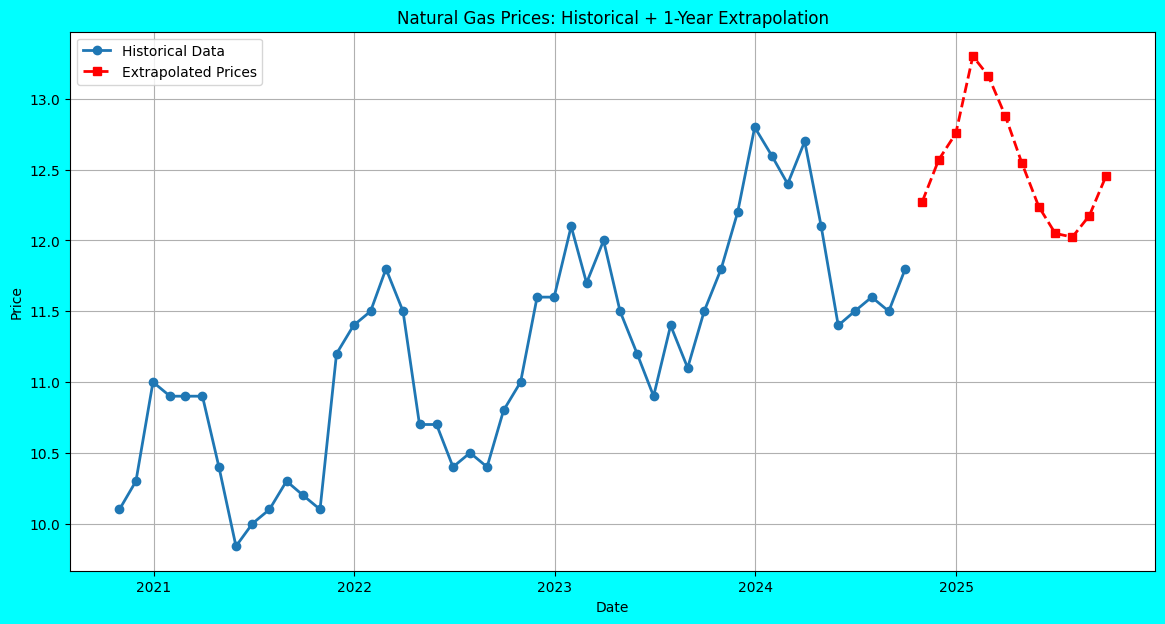

In [57]:
# Extrapolate for future year
last_date = df['Dates'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=30), 
                              end=last_date + timedelta(days=365), 
                              freq='M')

future_prices = [estimate_price(date) for date in future_dates]

# Visualize historical + extrapolated
plt.figure(figsize=(14, 7), facecolor = 'cyan')
plt.plot(df['Dates'], df['Prices'], 'o-', label='Historical Data', linewidth=2)
plt.plot(future_dates, future_prices, 's--', label='Extrapolated Prices', linewidth=2, color='red')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices: Historical + 1-Year Extrapolation')
plt.legend()
plt.grid(True)
plt.show()

In [65]:
def price_contract(injection_dates, withdrawal_dates, 
                   injection_volumes, withdrawal_volumes,
                   injection_rate, withdrawal_rate, 
                   storage_rate, max_storage):
    """
    injection_dates: list of dates to inject gas
    withdrawal_dates: list of dates to withdraw gas
    injection_volumes: list of volumes (MMBtu) for each injection
    withdrawal_volumes: list of volumes (MMBtu) for each withdrawal
    injection_rate: cost per MMBtu to inject
    withdrawal_rate: cost per MMBtu to withdraw
    storage_rate: cost per month to store (fixed monthly fee)
    max_storage: maximum storage capacity (MMBtu)
    """
    
    # Define first and last dates
    first_injection = min(injection_dates)
    last_withdrawal = max(withdrawal_dates)
    
    # Calculate purchase costs (market price + injection fees)
    purchase_cost = sum(estimate_price(date) * volume + injection_rate * volume 
                    for date, volume in zip(injection_dates, injection_volumes))

    # Calculate sale revenue (market price - withdrawal fees)
    sale_revenue = sum(estimate_price(date) * volume - withdrawal_rate * volume 
                   for date, volume in zip(withdrawal_dates, withdrawal_volumes))
    
    # Calculate storage duration in months
    storage_months = ((last_withdrawal.year - first_injection.year) * 12 + 
                      (last_withdrawal.month - first_injection.month))
    storage_cost = storage_rate * storage_months
    
    # Create list of all transactions with (date, volume, type)
    transactions = []
    
    # Add injections (positive volumes)
    for date, volume in zip(injection_dates, injection_volumes):
        transactions.append((date, volume, 'injection'))
    
    # Add withdrawals (negative volumes)
    for date, volume in zip(withdrawal_dates, withdrawal_volumes):
        transactions.append((date, -volume, 'withdrawal'))
    
    # Sort by date
    transactions.sort(key=lambda x: x[0])
    
    # Track running inventory
    current_inventory = 0
    
    for date, volume, transaction_type in transactions:
        current_inventory += volume
        
        # Check if inventory goes negative
        if current_inventory < 0:
            return f"Error: Inventory goes negative on {date.date()}. Trying to withdraw more than available."
        
        # Check if exceeds capacity
        if current_inventory > max_storage:
            return f"Error: Inventory exceeds capacity on {date.date()}. Current: {current_inventory}, Max: {max_storage}"
    
    # Check if all gas is withdrawn by the end
    if current_inventory != 0:
        print(f"Warning: {current_inventory} MMBtu remains in storage at contract end.")
    
    # Calculate final contract value
    contract_value = sale_revenue - purchase_cost - storage_cost
    
    return contract_value


In [67]:
# Interactive input for contract pricing
print("=== Natural Gas Storage Contract Pricing ===\n")

# Get number of injections
num_injections = int(input("How many injection dates? "))
injection_dates = []
injection_volumes = []

for i in range(num_injections):
    date_str = input(f"Injection date {i+1} (YYYY-MM-DD): ")
    injection_dates.append(pd.Timestamp(date_str))
    volume = float(input(f"Injection volume {i+1} (MMBtu): "))
    injection_volumes.append(volume)

# Get number of withdrawals
num_withdrawals = int(input("\nHow many withdrawal dates? "))
withdrawal_dates = []
withdrawal_volumes = []

for i in range(num_withdrawals):
    date_str = input(f"Withdrawal date {i+1} (YYYY-MM-DD): ")
    withdrawal_dates.append(pd.Timestamp(date_str))
    volume = float(input(f"Withdrawal volume {i+1} (MMBtu): "))
    withdrawal_volumes.append(volume)

# Get contract parameters
injection_rate = float(input("Injection rate ($ per MMBtu): "))
withdrawal_rate = float(input("Withdrawal rate ($ per MMBtu): "))
storage_rate = float(input("Storage cost ($ per month): "))
max_storage = float(input("Maximum storage capacity (MMBtu): "))

# Calculate contract value
value = price_contract(injection_dates, withdrawal_dates,
                      injection_volumes, withdrawal_volumes,
                      injection_rate, withdrawal_rate,
                      storage_rate, max_storage)

if isinstance(value, str):  # Error message
    print(value)
else:
    print(f"\nContract Value: {value:,.2f}")


=== Natural Gas Storage Contract Pricing ===


Contract Value: -139,505.08
